## Assignment: $k$ Means Clustering


**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

**Q2.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the spending?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [3]:
# Your Phase 1 solution to the problem goes here.
!git clone https://github.com/rushilnanga/A04-clustering.git
%cd /content/A04-clustering/
!ls

Cloning into 'A04-clustering'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 206.60 KiB | 11.48 MiB/s, done.
/content/A04-clustering
A04-clustering	data  notebook.ipynb  README.md


In [4]:
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

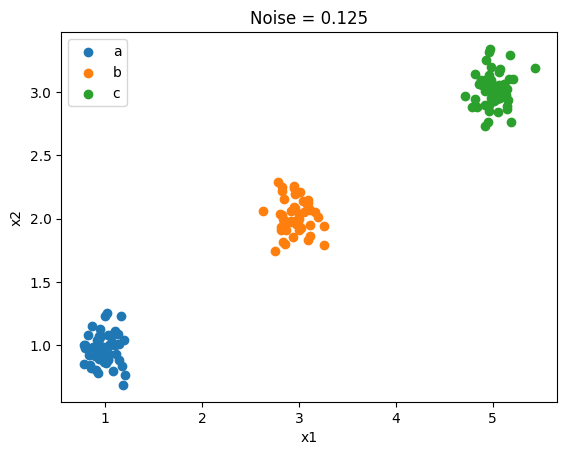

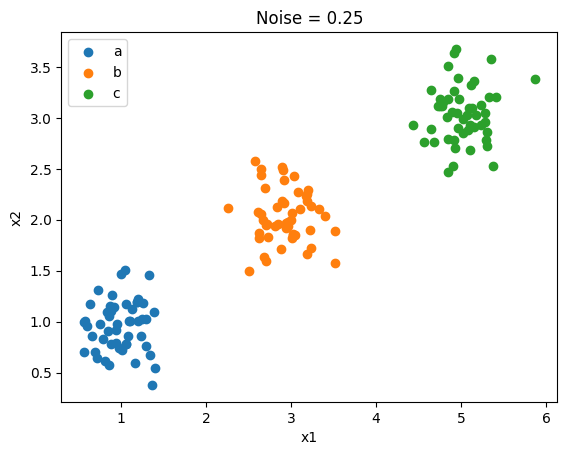

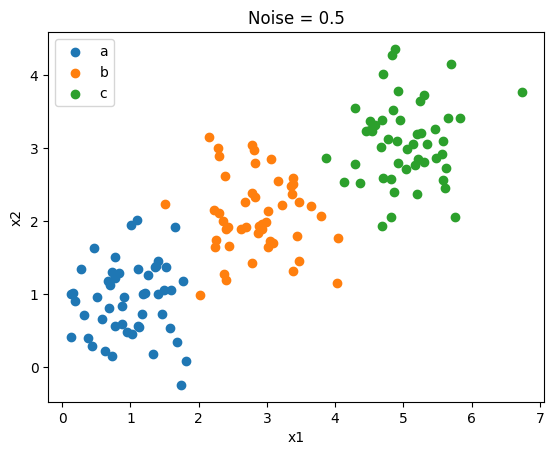

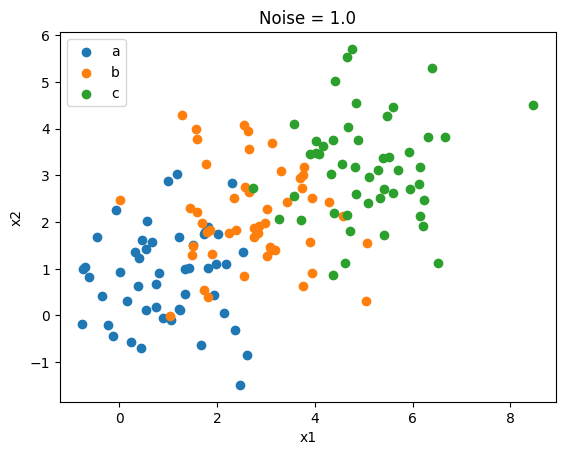

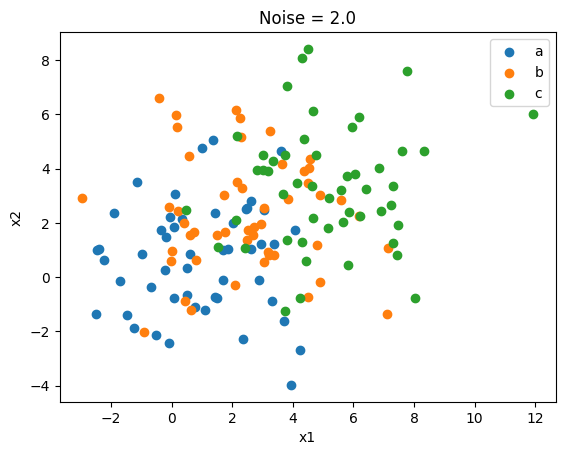

In [5]:
import matplotlib.pyplot as plt

datasets = [
    (df0_125, "Noise = 0.125"),
    (df0_25, "Noise = 0.25"),
    (df0_5, "Noise = 0.5"),
    (df1_0, "Noise = 1.0"),
    (df2_0, "Noise = 2.0")
]

for df, title in datasets:
    plt.figure()

    for group in ["a", "b", "c"]:
        data = df[df["group"] == group]
        plt.scatter(data["x1"], data["x2"], label=group)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.show()

    # As the noise increases, the clusters become less visually distinct. At low noise levels the three groups are clearly separated. As noise increases the points spread out and the groups begin to overlap. At the highest noise levels it becomes much harder to visually separate the three clusters.

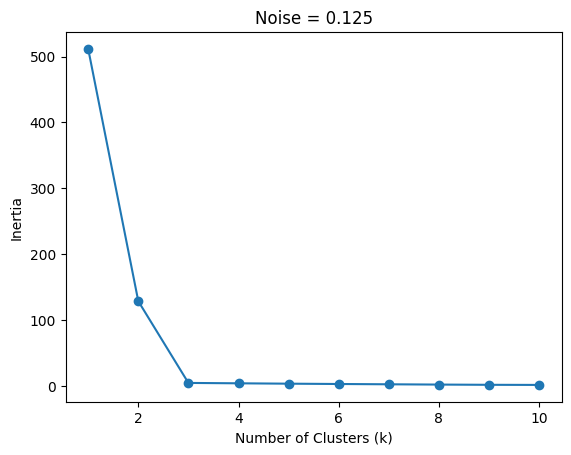

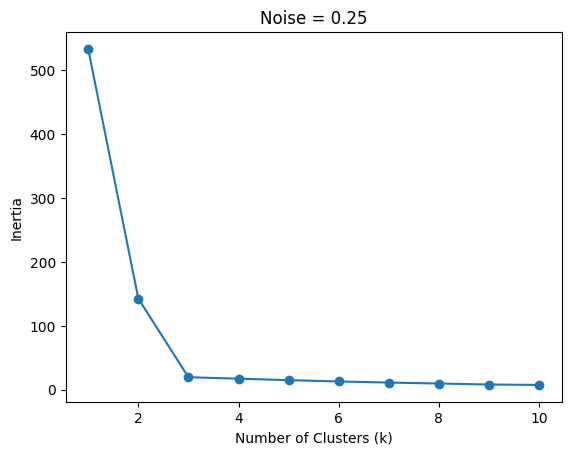

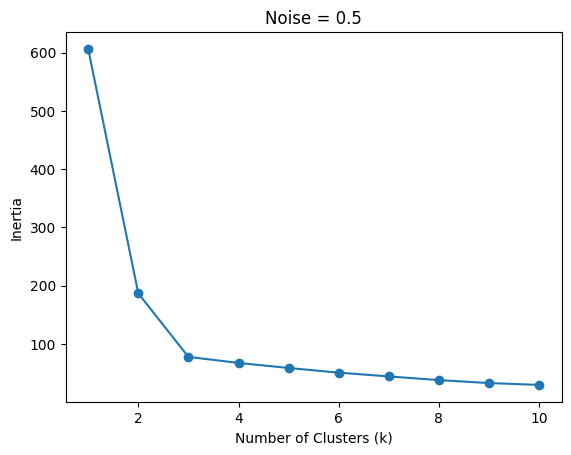

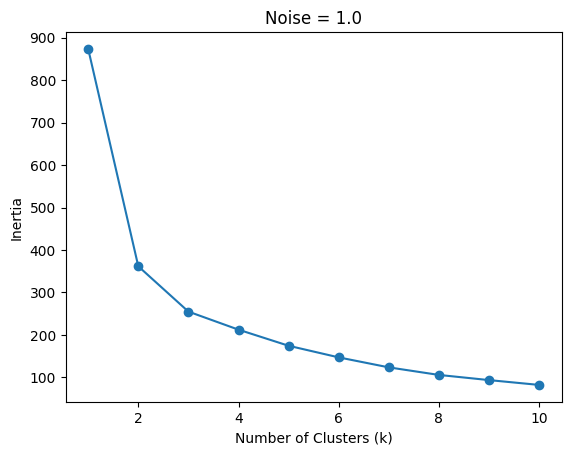

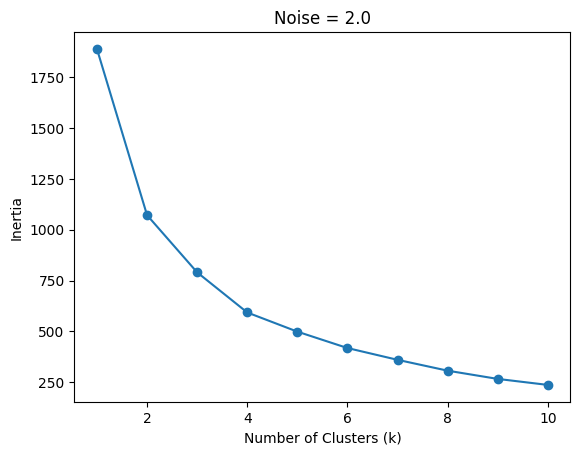

In [6]:
from sklearn.cluster import KMeans

for df, title in datasets:
    X = df[["x1", "x2"]]

    inertia = []

    for k in range(1, 11):
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        model.fit(X)
        inertia.append(model.inertia_)

    plt.figure()
    plt.plot(range(1, 11), inertia, marker="o")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.title(title)
    plt.show()

    # At lower noise levels the scree plots should have a clearer elbow around k = 3 as the data were generated from three groups. As noise increases the groups overlap more and the elbow becomes less obvious. This makes it harder to choose the correct number of clusters, and the overall inertia also increases as the data become more spread out.

1.4) The elbow is used to represent the point where adding another cluster stops producing a large improvement in the clustering. Before the elbow, increasing k greatly decreases the variation within the cluster. After the elbow, adding more clusters only gives smaller improvements. In this example, the low noise data shows an elbow near k = 3 because the data was generated from three groups. As the noise increases, the elbow becomes less clear because the groups overlap more.

In [9]:
import pandas as pd

sipri = pd.read_csv("data/SIPRI Military Expenditure Database.csv")

print(sipri.head())
print()
print(sipri.columns.tolist())
print()
print(sipri.shape)

sipri_2020 = sipri[sipri["Year"] == 2020].copy()
sipri_2020 = sipri_2020.dropna()

print(sipri_2020.shape)
print(sipri_2020.head())
print(sipri_2020.dtypes)

print(sipri_2020.dtypes)
print(sipri_2020.head())

# After filtering the data to 2020 and dropping rows with missing values there are 148 countries remaining. The four variables used for the analysis are already numeric so no further cleaning is required for these variables and the index column is not needed for the clustering analysis.

   index  Year      Country  Spending (2020 USD)  Percent of GDP  \
0      0  1988  Afghanistan                  NaN             NaN   
1      1  1989  Afghanistan                  NaN             NaN   
2      2  1990  Afghanistan                  NaN             NaN   
3      3  1991  Afghanistan                  NaN             NaN   
4      4  1992  Afghanistan                  NaN             NaN   

   Percent of Government Spending  Spending per Capita  
0                             NaN                  NaN  
1                             NaN                  NaN  
2                             NaN                  NaN  
3                             NaN                  NaN  
4                             NaN                  NaN  

['index', 'Year', 'Country', 'Spending (2020 USD)', 'Percent of GDP', 'Percent of Government Spending', 'Spending per Capita']

(5882, 7)
(148, 7)
     index  Year      Country  Spending (2020 USD)  Percent of GDP  \
32      32  2020  Afghanistan  

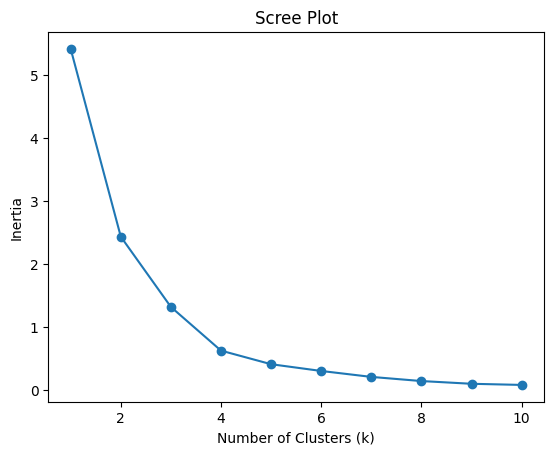

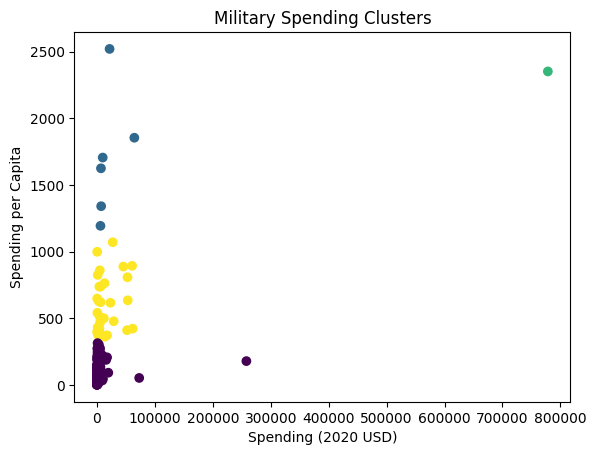

Spending (2020 USD)                               \
                               count           mean           std   
cluster_spending                                                    
0                              111.0    4859.185065  25405.739131   
1                                6.0   19443.362047  22861.507114   
2                                1.0  778397.200000           NaN   
3                               30.0   17077.591354  20583.053357   

                                                                              \
                            min            25%            50%            75%   
cluster_spending                                                               
0                      8.622460     130.010211     382.464677    2297.032353   
1                   6095.708713    7023.251766    8624.225729   18857.070183   
2                 778397.200000  778397.200000  778397.200000  778397.200000   
3                    405.790494    2294.039665    5857.060906   26296.001003   

                                Spending per Capita                           \
                            max               count         mean         std   
cluster_spending                                                               
0                 257973.429834               111.0    80.061470   83.501824   
1                  64558.400000                 6.0  1706.721916  466.375705   
2                 778397.200000                 1.0  2351.631858         NaN   
3                  61712.537169                30.0   607.478618  206.928757   

                                                                      \
                          min          25%          50%          75%   
cluster_spending                                                       
0                    0.580129    14.880549    47.056944   125.387558   
1                 1193.598730  1412.083201  1665.447478  1817.219993   
2                 2351.631858  2351.631858  2351.631858  2351.631858   
3                  362.467076   422.208252   579.004604   757.328513   

                               
                          max  
cluster_spending               
0                  314.201312  
1                 2520.398541  
2                 2351.631858  
3                 1070.623322

In [17]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

features = ["Spending (2020 USD)", "Spending per Capita"]

scaler = MinMaxScaler()
X = scaler.fit_transform(sipri_2020[features])

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Scree Plot")
plt.show()

model = KMeans(n_clusters=4, random_state=42, n_init=10)

sipri_2020["cluster_spending"] = model.fit_predict(X)

plt.scatter(
    sipri_2020["Spending (2020 USD)"],
    sipri_2020["Spending per Capita"],
    c=sipri_2020["cluster_spending"]
)

plt.xlabel("Spending (2020 USD)")
plt.ylabel("Spending per Capita")
plt.title("Military Spending Clusters")
plt.show()

sipri_2020.groupby("cluster_spending")[
    ["Spending (2020 USD)", "Spending per Capita"]
].describe()



In [22]:
sipri_2020[
    sipri_2020["Country"].str.contains("United States", case=False)
][
    ["Country", "Spending (2020 USD)", "Spending per Capita", "cluster_spending"]
]

,Country,Spending (2020 USD),Spending per Capita,cluster_spending
5540,United States of America,778397.2,2351.631858,2


In [20]:
sipri_2020[
    sipri_2020["Country"].str.contains("United States", case=False)
][
    ["Country", "Spending (2020 USD)", "Spending per Capita", "cluster_spending"]
]

# The scree plot shows an elbow around k = 4 so I selected four clusters. The clusters show clear differences in military spending. Cluster 0 contains most countries and generally has lower total spending and spending per capita. Cluster 1 contains a small group of countries with especially high spending per capita. Cluster 3 contains countries with moderately high spending compared with most countries. The United States is the only country in Cluster 2 because its total military spending is much higher than the other countries. Overall, the clusters separate countries based on both the total amount they spend and how much they spend per person.

Cluster 0
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Azerbaijan', 'Bangladesh', 'Belarus', 'Belize', 'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Congo, DR', 'Congo, Republic', 'Croatia', 'Czechia', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Ethiopia', 'Fiji', 'Gabon', 'Gambia, The', 'Georgia', 'Ghana', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kenya', 'Kosovo', 'Kyrgyz Republic', 'Lebanon', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Malaysia', 'Mali', 'Malta', 'Mauritania', 'Mauritius', 'Mexico', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Nicaragua', 'Niger', 'Nigeria', 'North Ma

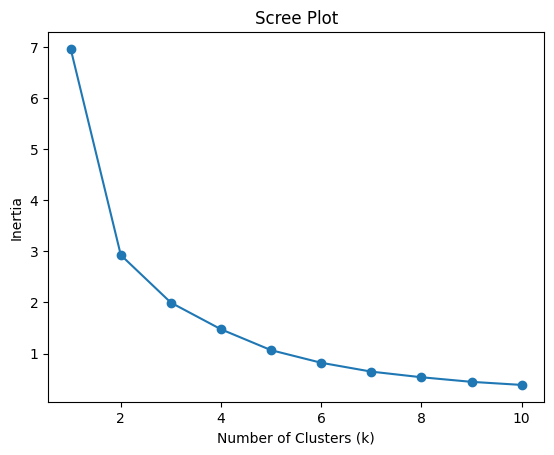

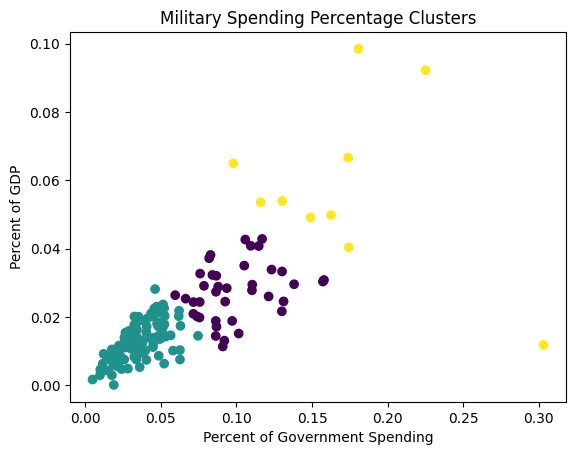

Percent of Government Spending                                \
                                         count      mean       std       min   
cluster_percent                                                                
0                                         39.0  0.098683  0.024125  0.059520   
1                                         99.0  0.035777  0.014549  0.004896   
2                                         10.0  0.171289  0.058725  0.097882   

                                                        Percent of GDP  \
                      25%       50%       75%       max          count   
cluster_percent                                                          
0                0.082430  0.092044  0.112633  0.157918           39.0   
1                0.025921  0.034261  0.047402  0.074624           99.0   
2                0.135010  0.168248  0.179081  0.303027           10.0   

                                                                             \
                     mean       std       min       25%       50%       75%   
cluster_percent                                                               
0                0.027412  0.008191  0.011317  0.021254  0.027781  0.032461   
1                0.012664  0.005681  0.000054  0.008393  0.013191  0.016752   
2                0.058071  0.024867  0.011742  0.049297  0.053729  0.066190   

                           
                      max  
cluster_percent            
0                0.042810  
1                0.028132  
2                0.098470

In [28]:
features2 = ["Percent of Government Spending", "Percent of GDP"]

scaler2 = MinMaxScaler()
X2 = scaler2.fit_transform(sipri_2020[features2])

inertia2 = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X2)
    inertia2.append(model.inertia_)

plt.plot(range(1, 11), inertia2, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Scree Plot")
plt.show()

model2 = KMeans(n_clusters=3, random_state=42, n_init=10)

sipri_2020["cluster_percent"] = model2.fit_predict(X2)

plt.scatter(
    sipri_2020["Percent of Government Spending"],
    sipri_2020["Percent of GDP"],
    c=sipri_2020["cluster_percent"]
)

plt.xlabel("Percent of Government Spending")
plt.ylabel("Percent of GDP")
plt.title("Military Spending Percentage Clusters")
plt.show()

sipri_2020.groupby("cluster_percent")[
    ["Percent of Government Spending", "Percent of GDP"]
].describe()



In [29]:
sipri_2020[
    sipri_2020["Country"].str.contains("United States", case=False)
][
    ["Country", "Percent of Government Spending",
     "Percent of GDP", "cluster_percent"]
]

,Country,Percent of Government Spending,Percent of GDP,cluster_percent
5540,United States of America,0.081976,0.037179,0


In [30]:
for cluster in sorted(sipri_2020["cluster_percent"].unique()):
    print("Cluster", cluster)
    print(
        sipri_2020[
            sipri_2020["cluster_percent"] == cluster
        ]["Country"].tolist()
    )
    print()

    # The scree plot has a less obvious elbow but I selected k = 3 because the decreases become more gradual after three clusters. Cluster 1 contains most countries and has the lowest military spending as a percentage of government spending and GDP. Cluster 0 has moderate values for both measures and includes the United States. Cluster 2 contains the countries with the highest percentages of government spending and GDP devoted to the military. Compared with 2.2, the United States no longer forms its own cluster because its military spending is less extreme when measured as a percentage rather than by total spending.

Cluster 0
['Bahrain', 'Bangladesh', 'Botswana', 'Brunei', 'Burkina Faso', 'Burundi', 'Cambodia', 'Central African Republic', 'Chad', 'Chile', 'Colombia', 'Congo, Republic', 'Ecuador', 'Equatorial Guinea', 'Gabon', 'Guinea', 'India', 'Iran', 'Iraq', 'Korea, South', 'Lebanon', 'Mali', 'Mauritania', 'Morocco', 'Myanmar', 'Namibia', 'Niger', 'Russia', 'Singapore', 'South Sudan', 'Sri Lanka', 'Sudan', 'Taiwan', 'Togo', 'Tunisia', 'Turkey', 'Uganda', 'Ukraine', 'United States of America']

Cluster 1
['Afghanistan', 'Albania', 'Angola', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Belize', 'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cameroon', 'Canada', 'Cape Verde', 'China', 'Congo, DR', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Dominican Republic', 'Egypt', 'El Salvador', 'Estonia', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gambia, The', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'Indonesia'

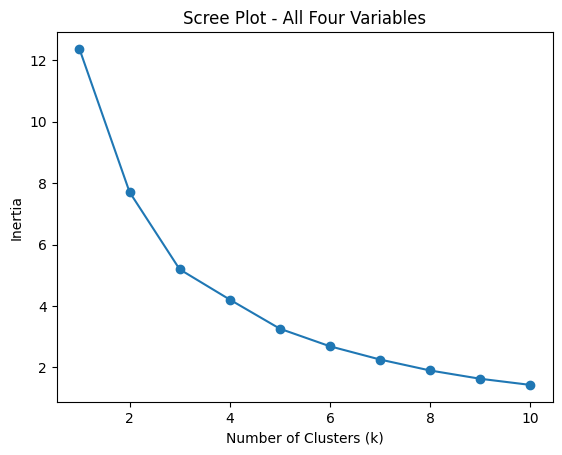

Spending (2020 USD)                                             \
                          count           mean            std          min   
cluster_all                                                                  
0                          31.0    8786.086602   17901.909108   162.373364   
1                           6.0  147964.582042  309635.189564  6095.708713   
2                         111.0    7086.472777   26479.379918     8.622460   

                                                                     \
                     25%           50%           75%            max   
cluster_all                                                           
0             467.787851   1404.787234   7739.166193   72937.064048   
1            7700.424616  15897.570598  53872.942442  778397.200000   
2             130.010211    567.650747   3910.107493  257973.429834   

            Spending per Capita               ...  \
                          count         mean  ...   
cluster_all                                   ...   
0                          31.0   212.689100  ...   
1                           6.0  1875.150751  ...   
2                         111.0   196.926833  ...   

            Percent of Government Spending           Percent of GDP            \
                                       75%       max          count      mean   
cluster_all                                                                     
0                                 0.134663  0.303027           31.0  0.033492   
1                                 0.164503  0.225050            6.0  0.062634   
2                                 0.050505  0.092044          111.0  0.013419   

                                                                         
                  std       min       25%       50%       75%       max  
cluster_all                                                              
0            0.011449  0.011742  0.027560  0.032024  0.040531  0.066600  
1            0.028275  0.029429  0.041272  0.059257  0.085398  0.098470  
2            0.005996  0.000054  0.008873  0.013589  0.017769  0.028132  

[3 rows x 32 columns]

In [34]:
features3 = [
    "Spending (2020 USD)",
    "Spending per Capita",
    "Percent of Government Spending",
    "Percent of GDP"
]

scaler3 = MinMaxScaler()
X3 = scaler3.fit_transform(sipri_2020[features3])

inertia3 = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X3)
    inertia3.append(model.inertia_)

plt.plot(range(1, 11), inertia3, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Scree Plot - All Four Variables")
plt.show()

model3 = KMeans(n_clusters=3, random_state=42, n_init=10)

sipri_2020["cluster_all"] = model3.fit_predict(X3)

sipri_2020.groupby("cluster_all")[features3].describe()

In [35]:
sipri_2020[
    sipri_2020["Country"].str.contains("United States", case=False)
][
    ["Country", "Spending (2020 USD)", "Spending per Capita",
     "Percent of Government Spending", "Percent of GDP", "cluster_all"]
]

,Country,Spending (2020 USD),Spending per Capita,Percent of Government Spending,Percent of GDP,cluster_all
5540,United States of America,778397.2,2351.631858,0.081976,0.037179,1


In [36]:
for cluster in sorted(sipri_2020["cluster_all"].unique()):
    print("Cluster", cluster)
    print(
        sipri_2020[
            sipri_2020["cluster_all"] == cluster
        ]["Country"].tolist()
    )
    print()

    # The scree plot suggests an elbow around k = 3 so I selected three clusters when using all four variables. Cluster 2 contains most countries and generally has lower military spending measures. Cluster 0 contains countries with relatively higher military spending as a percentage of government spending and GDP. Cluster 1 contains countries with especially high overall or per capita military spending including the United States. Compared with 2.2, the United States no longer forms its own cluster because the percentage measures are now also included. The results combine patterns from both 2.2 and 2.3

Cluster 0
['Algeria', 'Armenia', 'Azerbaijan', 'Bahrain', 'Belarus', 'Botswana', 'Brunei', 'Burkina Faso', 'Cambodia', 'Chad', 'Colombia', 'Congo, Republic', 'Equatorial Guinea', 'India', 'Iran', 'Iraq', 'Jordan', 'Korea, South', 'Lebanon', 'Mali', 'Mauritania', 'Morocco', 'Myanmar', 'Namibia', 'Pakistan', 'Russia', 'Taiwan', 'Togo', 'Tunisia', 'Uganda', 'Ukraine']

Cluster 1
['Israel', 'Kuwait', 'Oman', 'Saudi Arabia', 'Singapore', 'United States of America']

Cluster 2
['Afghanistan', 'Albania', 'Angola', 'Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belgium', 'Belize', 'Benin', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Burundi', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chile', 'China', 'Congo, DR', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia, The', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', '

2.5) Yes, the k-MC algorithm found useful patterns in military spending. It separated countries with low military spending from countries with higher spending and countries that allocate a larger share of their government spending or GDP to the military. It also showed that the clusters change depending on which variables are used. For example, the United States formed its own cluster when using total spending and spending per capita, but it was grouped with other high spending countries when all four variables were included.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]